# 02 — Quantum Fourier Transform (QFT) and Quantum Phase Estimation (QPE) with Qiskit

This Google Colab notebook is based on the code examples in IBM Quantum Learning's **Quantum algorithms: Phase estimation** lesson:

https://quantum.cloud.ibm.com/learning/en/courses/utility-scale-quantum-computing/quantum-phase-estimation

> **Compatibility note:** The IBM lesson uses the older `QFT` circuit class. Current Qiskit recommends `QFTGate`, so the inverse-QFT code below uses `QFTGate(...).inverse()`.


## 1. Install the required packages

In [14]:
# Run this cell first in Google Colab.
%pip install -q "qiskit~=2.5.1" qiskit-aer "qiskit-ibm-runtime~=0.47.0" pylatexenc

## 2. Import libraries

In [61]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector, state_fidelity
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.circuit.library import QFTGate

from numpy import pi

import qiskit
print("Qiskit version:", qiskit.__version__)

Qiskit version: 2.5.2


# Part A — Quantum Fourier Transform (QFT)

For an $n$-qubit computational basis state $|x\rangle$, the QFT maps the state into a Fourier-basis representation whose qubits encode phase information.

The examples below construct the QFT explicitly using Hadamard, controlled-phase, and SWAP gates.


## 3. Manual construction of a 3-qubit QFT

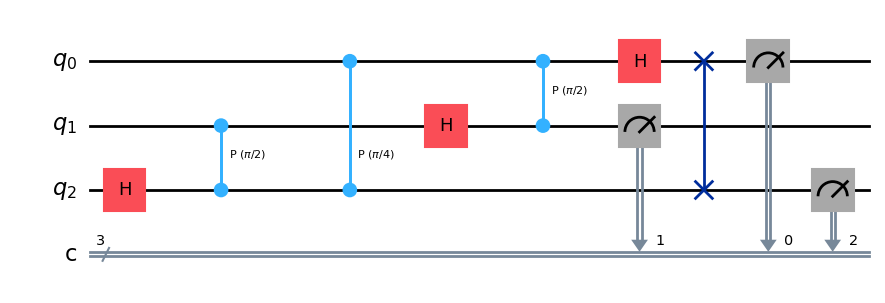

In [25]:
# Prepare a 3-qubit QFT circuit
qr = QuantumRegister(3, "q")
cr = ClassicalRegister(3, "c")
qc = QuantumCircuit(qr, cr)

qc.h(2)
qc.cp(pi / 2, 1, 2)  # Controlled-phase from qubit 1 to qubit 2
qc.cp(pi / 4, 0, 2)  # Controlled-phase from qubit 0 to qubit 2

qc.h(1)
qc.cp(pi / 2, 0, 1)  # Controlled-phase from qubit 0 to qubit 1

qc.h(0)

qc.swap(0, 2)

qc.measure([0, 1, 2], [0, 1, 2])

qc.draw(output="mpl")

{'110': 120, '011': 145, '111': 113, '000': 111, '010': 133, '100': 121, '101': 134, '001': 147}


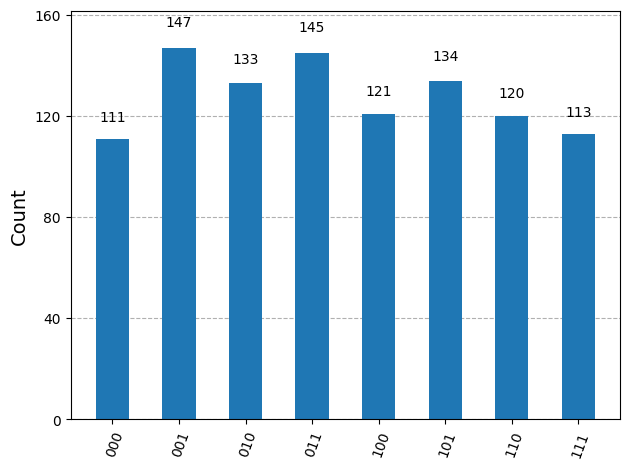

In [26]:
# Simulate the 3-qubit QFT circuit
simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print(counts)
plot_histogram(counts)

## 4. Four-qubit QFT

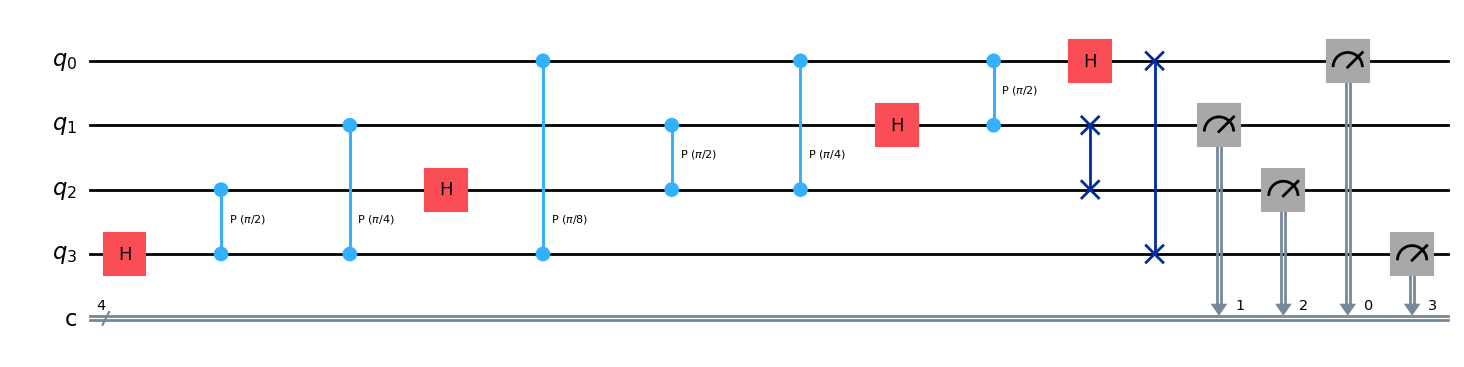

In [40]:
qr4 = QuantumRegister(4, "q")
cr4 = ClassicalRegister(4, "c")
qft4 = QuantumCircuit(qr4, cr4)

qft4.h(3)
qft4.cp(pi / 2, 2, 3)
qft4.cp(pi / 4, 1, 3)
qft4.cp(pi / 8, 0, 3)

qft4.h(2)
qft4.cp(pi / 2, 1, 2)
qft4.cp(pi / 4, 0, 2)

qft4.h(1)
qft4.cp(pi / 2, 0, 1)

qft4.h(0)

qft4.swap(0, 3)
qft4.swap(1, 2)

qft4.measure([0, 1, 2, 3], [0, 1, 2, 3])

qft4.draw(output="mpl")

{'0111': 55, '0011': 70, '1110': 58, '1100': 64, '1010': 57, '1000': 64, '0110': 76, '1101': 66, '0100': 79, '1001': 57, '0101': 55, '0000': 72, '0010': 62, '0001': 57, '1111': 65, '1011': 67}


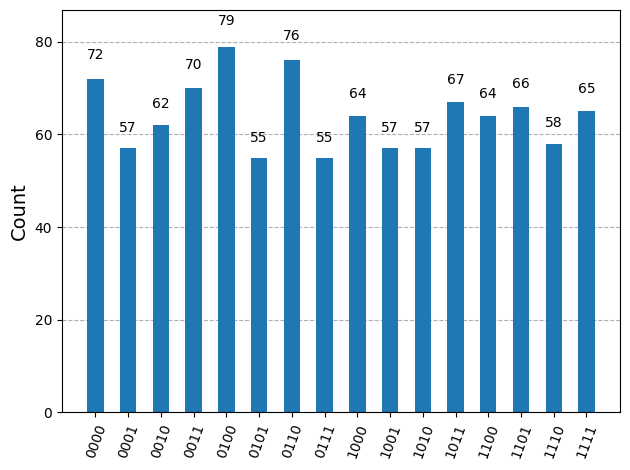

In [41]:
# Simulate the 4-qubit QFT circuit
simulator = AerSimulator()
result = simulator.run(qft4, shots=1024).result()
counts = result.get_counts()

print(counts)
plot_histogram(counts)

# A built-in QFT gate

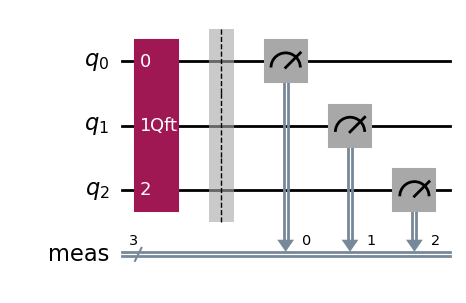

In [57]:
qc_builtin_qft = QuantumCircuit(3)

qc_builtin_qft.append(
    QFTGate(3),
    [0, 1, 2]
)

qc_builtin_qft.measure_all()

qc_builtin_qft.draw("mpl")

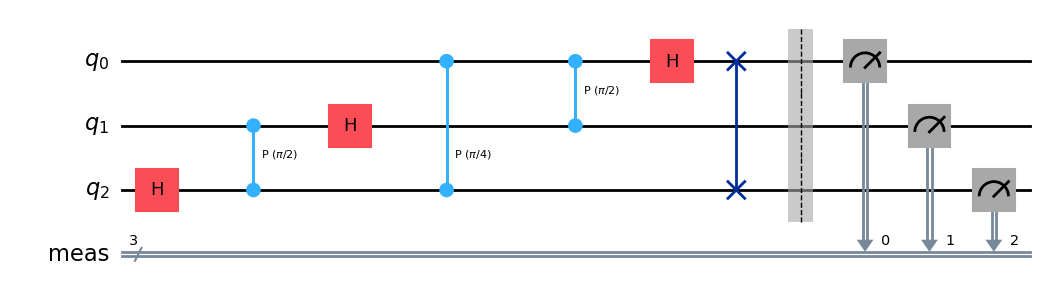

In [55]:
qc_builtin_decomposed = qc_builtin_qft.decompose()

qc_builtin_decomposed.draw("mpl")

# Comparing built-in QFT with manually designed QFT circuit

In [60]:
from qiskit import transpile

simulator = AerSimulator()

# Transpile both circuits for AerSimulator
qc_manual_transpiled = transpile(qc, simulator)
qc_builtin_transpiled = transpile(qc_builtin_qft, simulator)

# Run manual QFT
qft_manual_result = simulator.run(
    qc_manual_transpiled,
    shots=1024
).result()

counts_manual = qft_manual_result.get_counts()

# Run built-in QFTGate
qc_builtin_result = simulator.run(
    qc_builtin_transpiled,
    shots=1024
).result()

counts_builtin = qc_builtin_result.get_counts()

print("Manual QFT:")
print(counts_manual)

print("\nBuilt-in QFTGate:")
print(counts_builtin)

Manual QFT:
{'100': 143, '110': 127, '001': 115, '010': 137, '000': 138, '111': 116, '011': 120, '101': 128}

Built-in QFTGate:
{'001': 117, '010': 131, '000': 105, '110': 120, '111': 138, '011': 135, '101': 123, '100': 155}


In [67]:
qc_manual_no_measure = qc.remove_final_measurements(inplace=False)

qc_builtin_no_measure = qc_builtin_qft.remove_final_measurements(inplace=False)

sv_manual = Statevector.from_instruction(qc_manual_no_measure)

sv_builtin = Statevector.from_instruction(qc_builtin_no_measure)

prob_manual = sv_manual.probabilities_dict()
prob_builtin = sv_builtin.probabilities_dict()

print("Manual QFT probabilities:")
for state, prob in prob_manual.items():
    print(f"{str(state)} : {float(prob):.3f}")

print("\nBuilt-in QFTGate probabilities:")
for state, prob in prob_builtin.items():
    print(f"{str(state)} : {float(prob):.3f}")

Manual QFT probabilities:
000 : 0.125
001 : 0.125
010 : 0.125
011 : 0.125
100 : 0.125
101 : 0.125
110 : 0.125
111 : 0.125

Built-in QFTGate probabilities:
000 : 0.125
001 : 0.125
010 : 0.125
011 : 0.125
100 : 0.125
101 : 0.125
110 : 0.125
111 : 0.125


# Part B — Quantum Phase Estimation (QPE)

Suppose

$$
U|\psi\rangle=e^{2\pi i\theta}|\psi\rangle .
$$

Quantum Phase Estimation estimates the unknown phase $\theta$ by:

1. preparing a counting register,
2. applying Hadamard gates,
3. applying controlled powers of $U$,
4. applying the inverse QFT,
5. measuring the counting register.


## 5. QPE example: estimate the phase of the T gate

For the T gate,

$$
T|1\rangle=e^{i\pi/4}|1\rangle
          =e^{2\pi i(1/8)}|1\rangle,
$$

so the expected phase is

$$
\theta=\frac{1}{8}.
$$


### Step 1 — Prepare the eigenstate $|1\rangle$

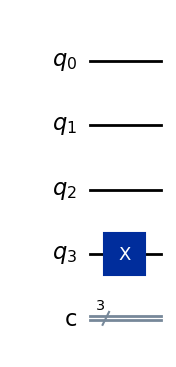

In [42]:
qpe = QuantumCircuit(4, 3)

# Qubit 3 is the eigenstate register.
qpe.x(3)

qpe.draw(output="mpl")

### Step 2 — Put the three counting qubits into superposition

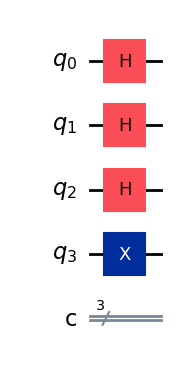

In [43]:
for qubit in range(3):
    qpe.h(qubit)

qpe.draw(output="mpl")

### Step 3 — Controlled powers of the T operation

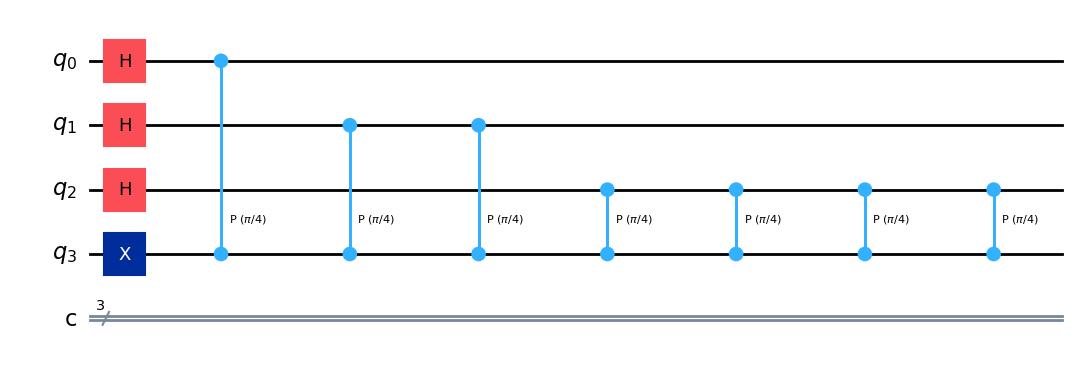

In [44]:
repetitions = 1

for counting_qubit in range(3):
    for _ in range(repetitions):
        qpe.cp(pi / 4, counting_qubit, 3)  # Controlled-U
    repetitions *= 2

qpe.draw(output="mpl")

### Step 4 — Apply the inverse QFT

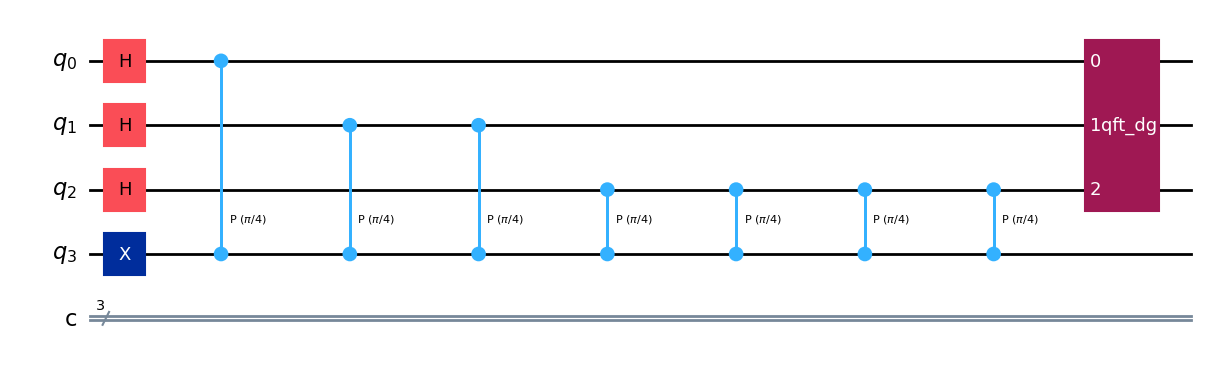

In [45]:
# Current-Qiskit form of the inverse QFT.
qpe.append(QFTGate(3).inverse(), [0, 1, 2])

qpe.draw(output="mpl")

### Step 5 — Measure the counting register

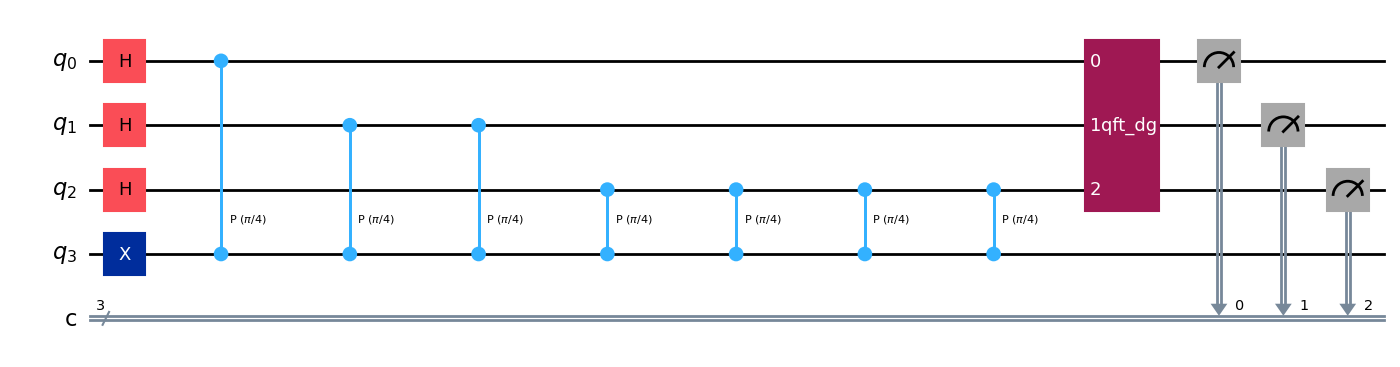

In [46]:
for n in range(3):
    qpe.measure(n, n)

qpe.draw(output="mpl")

### Simulate the QPE circuit

{'001': 2048}


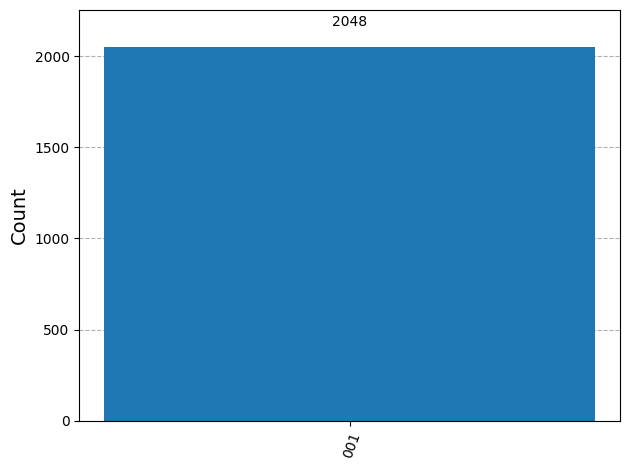

In [47]:
aer_sim = AerSimulator()
shots = 2048

pm = generate_preset_pass_manager(
    backend=aer_sim,
    optimization_level=1
)
t_qpe = pm.run(qpe)

sampler = Sampler(mode=aer_sim)
job = sampler.run([t_qpe], shots=shots)
result = job.result()

answer = result[0].data.c.get_counts()
print(answer)

plot_histogram(answer)

The expected dominant measurement is `001`.

With three counting qubits,

$$
\theta=\frac{1}{2^3}=\frac18.
$$


### Convert the most probable bit string into a phase estimate

In [48]:
most_likely = max(answer, key=answer.get)
measured_integer = int(most_likely, 2)
theta_estimate = measured_integer / (2**3)

print("Most likely bit string:", most_likely)
print("Measured integer:", measured_integer)
print("Estimated theta:", theta_estimate)

Most likely bit string: 001
Measured integer: 1
Estimated theta: 0.125


## 6. QPE example: estimate $\theta=1/3$

Choose a phase gate satisfying

$$
U|1\rangle=e^{2\pi i/3}|1\rangle .
$$

Thus the controlled-phase angle is

$$
\lambda=\frac{2\pi}{3}.
$$


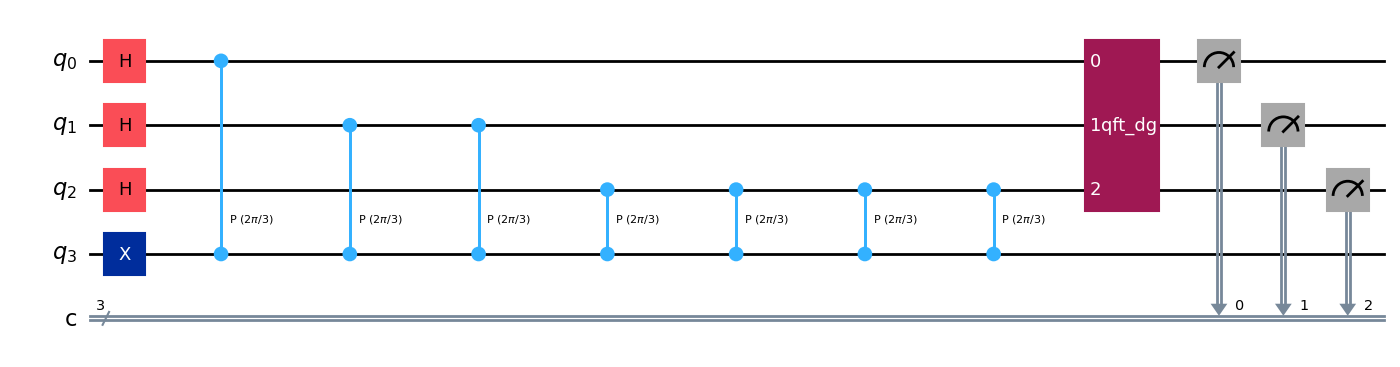

In [49]:
# Create and set up the circuit
qpe_one_third = QuantumCircuit(4, 3)

# Apply H gates to the counting qubits
for qubit in range(3):
    qpe_one_third.h(qubit)

# Prepare the eigenstate |1>
qpe_one_third.x(3)

# Controlled-U operations
angle = 2 * pi / 3
repetitions = 1

for counting_qubit in range(3):
    for _ in range(repetitions):
        qpe_one_third.cp(angle, counting_qubit, 3)
    repetitions *= 2

# Inverse QFT
qpe_one_third.append(QFTGate(3).inverse(), [0, 1, 2])

# Measure the counting register
for n in range(3):
    qpe_one_third.measure(n, n)

qpe_one_third.draw(output="mpl")

{'001': 139, '011': 2812, '010': 689, '100': 208, '000': 57, '101': 81, '111': 53, '110': 57}


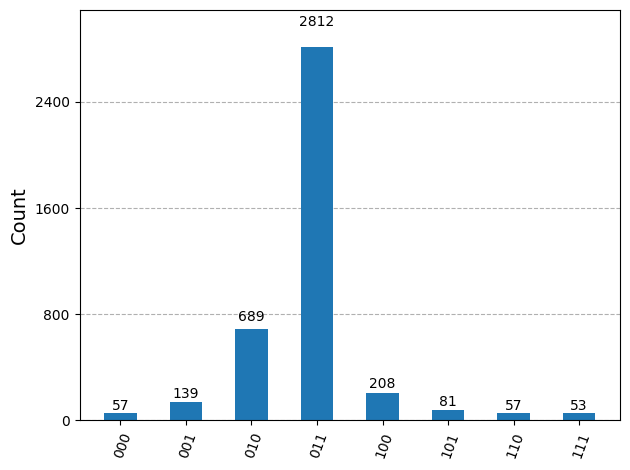

In [50]:
aer_sim = AerSimulator()
shots = 4096

pm = generate_preset_pass_manager(
    backend=aer_sim,
    optimization_level=1
)
t_qpe_one_third = pm.run(qpe_one_third)

sampler = Sampler(mode=aer_sim)
job = sampler.run([t_qpe_one_third], shots=shots)
result_one_third = job.result()

answer_one_third = result_one_third[0].data.c.get_counts()
print(answer_one_third)

plot_histogram(answer_one_third)

In [51]:
most_likely = max(answer_one_third, key=answer_one_third.get)
measured_integer = int(most_likely, 2)
theta_estimate = measured_integer / (2**3)

print("Most likely bit string:", most_likely)
print("Measured integer:", measured_integer)
print("Estimated theta:", theta_estimate)
print("Exact theta:", 1/3)

Most likely bit string: 011
Measured integer: 3
Estimated theta: 0.375
Exact theta: 0.3333333333333333


Because $1/3$ cannot be represented exactly using only three binary fractional bits, the QPE measurement is distributed among nearby representable phases. Increasing the number of counting qubits improves the phase resolution.


## 7. Summary

This notebook implemented the principal code examples from the IBM Quantum QFT/QPE lesson:

- explicit 3-qubit QFT,
- explicit 4-qubit QFT,
- comparison between built-in QFT and manually designed QFT,
- T-gate phase estimation with expected $\theta=1/8$,
- phase estimation for $\theta=1/3$,
- local Aer simulation